# California Housing New Listings — PCA of Macro Feature Space

**Scope:** State of California · 2020-01 through 2025-12
**Target:** Year-over-year % change in CA new home listing count
**Approach:** Collect 25+ FRED macro series → PCA → inspect singular-value distribution
**Key mandated feature:** Rate spread = GS10(t) − GS10(t − 120 months)
**Data pulled:** 2026-02-25 (public FRED CSV endpoint, no API key required)


In [1]:
from __future__ import annotations

import io
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import requests
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
pd.options.display.float_format = "{:.4f}".format

FRED_BASE = "https://fred.stlouisfed.org/graph/fredgraph.csv"
DATA_DIR  = os.path.join(os.path.dirname(os.getcwd()), "data")
os.makedirs(DATA_DIR, exist_ok=True)
print("Imports OK · data dir:", DATA_DIR)


Imports OK · data dir: /Users/youtao/code/claude_code/lock_in/data


## 1. Data Collection

In [2]:
def fetch_fred(series_id: str, start: str = "2010-01-01") -> pd.Series | None:
    """Fetch a FRED series via public CSV; return monthly pd.Series or None."""
    url = f"{FRED_BASE}?id={series_id}"
    try:
        r = requests.get(url, timeout=30)
        r.raise_for_status()
    except Exception as exc:
        print(f"  FAILED {series_id}: {exc}")
        return None

    df = pd.read_csv(io.StringIO(r.text), parse_dates=["observation_date"])
    s = (
        df.set_index("observation_date")[series_id]
        .replace(".", np.nan)
        .astype(float)
    )
    s.name = series_id
    s = s[s.index >= start]

    if s.empty:
        print(f"  EMPTY  {series_id}")
        return None

    # Resample to month-start frequency
    s_m = s.resample("MS").mean()
    # Quarterly (or lower) series: >50% NaN after monthly resample → interpolate
    if s_m.isna().mean() > 0.50:
        s_m = s_m.interpolate(method="linear")
    else:
        s_m = s_m.ffill()

    return s_m


In [3]:
# ── Feature series (series_id → description) ─────────────────────────────────
#   Pull start dates:
#     GS10  → 2010-01-01  (need 10-yr lookback for 2020 rate spread)
#     others → 2017-01-01  (need 3 yrs prior to 2020 for YoY transforms)

FEATURE_SERIES: dict[str, tuple[str, str]] = {
    # id : (start_date, description)
    # --- Interest rates / spreads ---
    "GS10":         ("2010-01-01", "10-Year Treasury Constant Maturity Rate"),
    "MORTGAGE30US": ("2017-01-01", "30-Year Fixed Mortgage Rate"),
    "MORTGAGE15US": ("2017-01-01", "15-Year Fixed Mortgage Rate"),
    "FEDFUNDS":     ("2017-01-01", "Federal Funds Effective Rate"),
    "T10Y2Y":       ("2017-01-01", "10Y−2Y Treasury Yield Spread (daily→monthly)"),
    "T10Y3M":       ("2017-01-01", "10Y−3M Treasury Yield Spread (daily→monthly)"),
    # --- Inflation ---
    "CPIAUCSL":     ("2017-01-01", "CPI All Urban Consumers (SA)"),
    "CPILFESL":     ("2017-01-01", "Core CPI ex Food & Energy (SA)"),
    "DCOILWTICO":   ("2017-01-01", "WTI Crude Oil Price (daily→monthly)"),
    # --- Labor ---
    "UNRATE":       ("2017-01-01", "National Unemployment Rate (SA)"),
    "CAUR":         ("2017-01-01", "California Unemployment Rate (SA)"),
    "CANRSA":       ("2017-01-01", "California Nonfarm Employment (SA)"),
    "ICSA":         ("2017-01-01", "Initial Jobless Claims (weekly→monthly)"),
    # --- Output & income ---
    "GDPC1":        ("2017-01-01", "Real GDP, quarterly chained 2017 USD"),
    "DSPIC96":      ("2017-01-01", "Real Disposable Personal Income (SA)"),
    "PSAVERT":      ("2017-01-01", "Personal Savings Rate"),
    # --- National housing ---
    "HOUST":        ("2017-01-01", "Housing Starts, SA (thousands)"),
    "PERMIT":       ("2017-01-01", "Housing Permits, SA (thousands)"),
    "CSUSHPISA":    ("2017-01-01", "Case-Shiller National HPI (SA)"),
    # --- California housing ---
    "CASTHPI":      ("2017-01-01", "California FHFA All-Transactions HPI (quarterly)"),
    "CABPPRIVSA":   ("2017-01-01", "California Building Permits, SA"),
    # --- Financial markets ---
    "SP500":        ("2017-01-01", "S&P 500 Index (daily→monthly)"),
    "VIXCLS":       ("2017-01-01", "CBOE VIX Volatility Index (daily→monthly)"),
    "M2SL":         ("2017-01-01", "M2 Money Supply (SA)"),
    # --- Consumer ---
    "UMCSENT":      ("2017-01-01", "U of Michigan Consumer Sentiment Index"),
}

# Target: CA new listing count (try multiple candidate IDs)
CA_LISTING_CANDIDATES = [
    "NEWLISCOUCA",  # state-level, postal abbreviation
    "NEWLISCOU06",  # state-level, FIPS 06
]

print(f"Catalog: {len(FEATURE_SERIES)} feature series + {len(CA_LISTING_CANDIDATES)} target candidates")


Catalog: 25 feature series + 2 target candidates


In [4]:
print("=" * 60)
print("Fetching feature series from FRED …")
print("=" * 60)

raw: dict[str, pd.Series] = {}
for sid, (start, desc) in FEATURE_SERIES.items():
    print(f"  {sid:<16} {desc[:45]:<45}", end="  ")
    s = fetch_fred(sid, start=start)
    if s is not None:
        raw[sid] = s
        print(f"OK  {s.index[0].date()} – {s.index[-1].date()}  ({len(s):3d} obs)")
    else:
        print("SKIPPED")

print()
print("=" * 60)
print("Fetching CA new listing count (target) …")
print("=" * 60)

ca_listings: pd.Series | None = None
for candidate in CA_LISTING_CANDIDATES:
    print(f"  Trying {candidate} …", end="  ")
    s = fetch_fred(candidate, start="2017-01-01")
    if s is not None:
        ca_listings = s
        ca_listings.name = "NEWLISCOUCA"
        print(f"SUCCESS  {s.index[0].date()} – {s.index[-1].date()}  ({len(s):3d} obs)")
        break
    else:
        print("not found")

if ca_listings is None:
    print("\nWARNING: CA new listing series not found.")
    print("  Check FRED for the correct series ID and update CA_LISTING_CANDIDATES.")

print(f"\nSuccessfully loaded {len(raw)}/{len(FEATURE_SERIES)} feature series.")


Fetching feature series from FRED …
  GS10             10-Year Treasury Constant Maturity Rate        OK  2010-01-01 – 2026-02-01  (194 obs)
  MORTGAGE30US     30-Year Fixed Mortgage Rate                    OK  2017-01-01 – 2026-02-01  (110 obs)
  MORTGAGE15US     15-Year Fixed Mortgage Rate                    OK  2017-01-01 – 2026-02-01  (110 obs)
  FEDFUNDS         Federal Funds Effective Rate                   OK  2017-01-01 – 2026-02-01  (110 obs)
  T10Y2Y           10Y−2Y Treasury Yield Spread (daily→monthly)   OK  2017-01-01 – 2026-03-01  (111 obs)
  T10Y3M           10Y−3M Treasury Yield Spread (daily→monthly)   OK  2017-01-01 – 2026-03-01  (111 obs)
  CPIAUCSL         CPI All Urban Consumers (SA)                   OK  2017-01-01 – 2026-01-01  (109 obs)
  CPILFESL         Core CPI ex Food & Energy (SA)                 OK  2017-01-01 – 2026-01-01  (109 obs)
  DCOILWTICO       WTI Crude Oil Price (daily→monthly)            OK  2017-01-01 – 2026-03-01  (111 obs)
  UNRATE           

## 2. Feature Engineering

- **Levels** for mean-reverting / already-stationary series (rates, spreads, unemployment)
- **YoY % change** for trending / non-stationary series (employment, HPI, GDP, equity)
- **Rate spread** = GS10(t) − GS10(t − 120 months) (10-year lock-in measure)

In [5]:
# Series kept as LEVELS (stationary / mean-reverting)
LEVEL_SERIES = {
    "GS10", "MORTGAGE30US", "MORTGAGE15US", "FEDFUNDS",
    "T10Y2Y", "T10Y3M",
    "UNRATE", "CAUR",
    "PSAVERT", "VIXCLS", "UMCSENT",
}

# Series transformed to YoY % change
YOY_SERIES = {
    "CPIAUCSL", "CPILFESL", "DCOILWTICO",
    "CANRSA", "ICSA",
    "GDPC1", "DSPIC96",
    "HOUST", "PERMIT", "CSUSHPISA",
    "CASTHPI", "CABPPRIVSA",
    "SP500", "M2SL",
}

features: dict[str, pd.Series] = {}

# ── Rate spread (10-year lookback) ───────────────────────────────────────────
if "GS10" in raw:
    gs10 = raw["GS10"]
    rate_spread = (gs10 - gs10.shift(120)).rename("rate_spread")
    features["rate_spread"] = rate_spread
    print(f"rate_spread: {rate_spread.dropna().shape[0]} valid obs  "
          f"(first non-NaN: {rate_spread.dropna().index[0].date()})")
else:
    print("WARNING: GS10 not available — cannot compute rate_spread")

# ── Level features ────────────────────────────────────────────────────────────
for sid in LEVEL_SERIES:
    if sid in raw:
        feat = raw[sid].rename(sid.lower())
        features[sid.lower()] = feat

# ── YoY % change features ─────────────────────────────────────────────────────
for sid in YOY_SERIES:
    if sid in raw:
        feat = (raw[sid].pct_change(12) * 100).rename(f"{sid.lower()}_yoy")
        features[f"{sid.lower()}_yoy"] = feat

# ── Target ────────────────────────────────────────────────────────────────────
if ca_listings is not None:
    target = (ca_listings.pct_change(12) * 100).rename("ca_newlisting_yoy")
else:
    target = None

print(f"\nTotal features engineered: {len(features)}")
for name, s in sorted(features.items()):
    print(f"  {name:<25}  {s.dropna().shape[0]:3d} valid obs")


rate_spread: 74 valid obs  (first non-NaN: 2020-01-01)

Total features engineered: 25
  cabpprivsa_yoy              96 valid obs
  casthpi_yoy                 94 valid obs
  caur                       108 valid obs
  cpiaucsl_yoy                97 valid obs
  cpilfesl_yoy                97 valid obs
  csushpisa_yoy               96 valid obs
  dcoilwtico_yoy              99 valid obs
  dspic96_yoy                 96 valid obs
  fedfunds                   110 valid obs
  gdpc1_yoy                   94 valid obs
  gs10                       194 valid obs
  houst_yoy                   96 valid obs
  icsa_yoy                    98 valid obs
  m2sl_yoy                    97 valid obs
  mortgage15us               110 valid obs
  mortgage30us               110 valid obs
  permit_yoy                  96 valid obs
  psavert                    108 valid obs
  rate_spread                 74 valid obs
  sp500_yoy                   99 valid obs
  t10y2y                     111 valid obs
  t10y3m   

In [6]:
ANALYSIS_START = "2020-01-01"
ANALYSIS_END   = "2025-12-31"

# Merge all features
df_feat = pd.DataFrame(features).loc[ANALYSIS_START:ANALYSIS_END]

# Coverage report
coverage = df_feat.notna().mean().sort_values(ascending=False)
print("Feature coverage (fraction non-NaN in analysis window):")
for col, cov in coverage.items():
    bar = "█" * int(cov * 20)
    print(f"  {col:<28} {bar:<20}  {cov:.0%}")

# Drop features with <70% coverage
df_feat = df_feat.loc[:, coverage >= 0.70]

# Drop rows with any NaN (need complete cases for PCA)
df_clean = df_feat.dropna()

# Align target
if target is not None:
    target_aligned = target.reindex(df_clean.index)
else:
    target_aligned = None

print(f"\nShape after coverage filter + dropna: {df_clean.shape}")
print(f"Analysis window: {df_clean.index[0].date()} – {df_clean.index[-1].date()}")
print(f"Features ({df_clean.shape[1]}): {list(df_clean.columns)}")
if target_aligned is not None:
    print(f"Target non-NaN: {target_aligned.notna().sum()} / {len(target_aligned)}")


Feature coverage (fraction non-NaN in analysis window):
  rate_spread                  ████████████████████  100%
  mortgage15us                 ████████████████████  100%
  dcoilwtico_yoy               ████████████████████  100%
  csushpisa_yoy                ████████████████████  100%
  cpiaucsl_yoy                 ████████████████████  100%
  houst_yoy                    ████████████████████  100%
  sp500_yoy                    ████████████████████  100%
  cpilfesl_yoy                 ████████████████████  100%
  permit_yoy                   ████████████████████  100%
  dspic96_yoy                  ████████████████████  100%
  icsa_yoy                     ████████████████████  100%
  cabpprivsa_yoy               ████████████████████  100%
  m2sl_yoy                     ████████████████████  100%
  caur                         ████████████████████  100%
  t10y2y                       ████████████████████  100%
  gs10                         ████████████████████  100%
  fedfunds      

## 3. Principal Component Analysis

In [7]:
# Standardize (zero mean, unit variance)
scaler  = StandardScaler()
X_scaled = scaler.fit_transform(df_clean)

# Full PCA — compute all components
pca = PCA(n_components=None, random_state=42)
pca.fit(X_scaled)

evr     = pca.explained_variance_ratio_          # fraction
cumvar  = np.cumsum(evr)
svs     = pca.singular_values_
n_pc    = len(svs)

print(f"PCA summary: {n_pc} components from {df_clean.shape[1]} features "
      f"over {df_clean.shape[0]} months")
print()
print(f"{'PC':<5}  {'Singular Value':>15}  {'Expl. Var %':>11}  {'Cumulative %':>12}")
print("─" * 50)
for i, (sv, ev, cv) in enumerate(zip(svs, evr, cumvar), 1):
    marker = " ◄" if cv <= 0.80 and (cv + evr[i - 1]) > 0.80 else (
             " ◄" if i == 1 else "")
    print(f"PC{i:<3}  {sv:>15.4f}  {ev*100:>10.2f}%  {cv*100:>11.2f}%{marker}")


PCA summary: 25 components from 25 features over 70 months

PC      Singular Value  Expl. Var %  Cumulative %
──────────────────────────────────────────────────
PC1            27.4812       43.16%        43.16% ◄
PC2            21.1029       25.45%        68.60% ◄
PC3            15.3865       13.53%        82.13%
PC4             8.0576        3.71%        85.84%
PC5             7.5240        3.23%        89.08%
PC6             7.4275        3.15%        92.23%
PC7             5.7105        1.86%        94.09%
PC8             5.0771        1.47%        95.56%
PC9             4.3284        1.07%        96.64%
PC10            3.9518        0.89%        97.53%
PC11            3.6252        0.75%        98.28%
PC12            3.0683        0.54%        98.82%
PC13            2.5422        0.37%        99.19%
PC14            1.9963        0.23%        99.41%
PC15            1.7282        0.17%        99.58%
PC16            1.6184        0.15%        99.73%
PC17            1.2359        0.09%

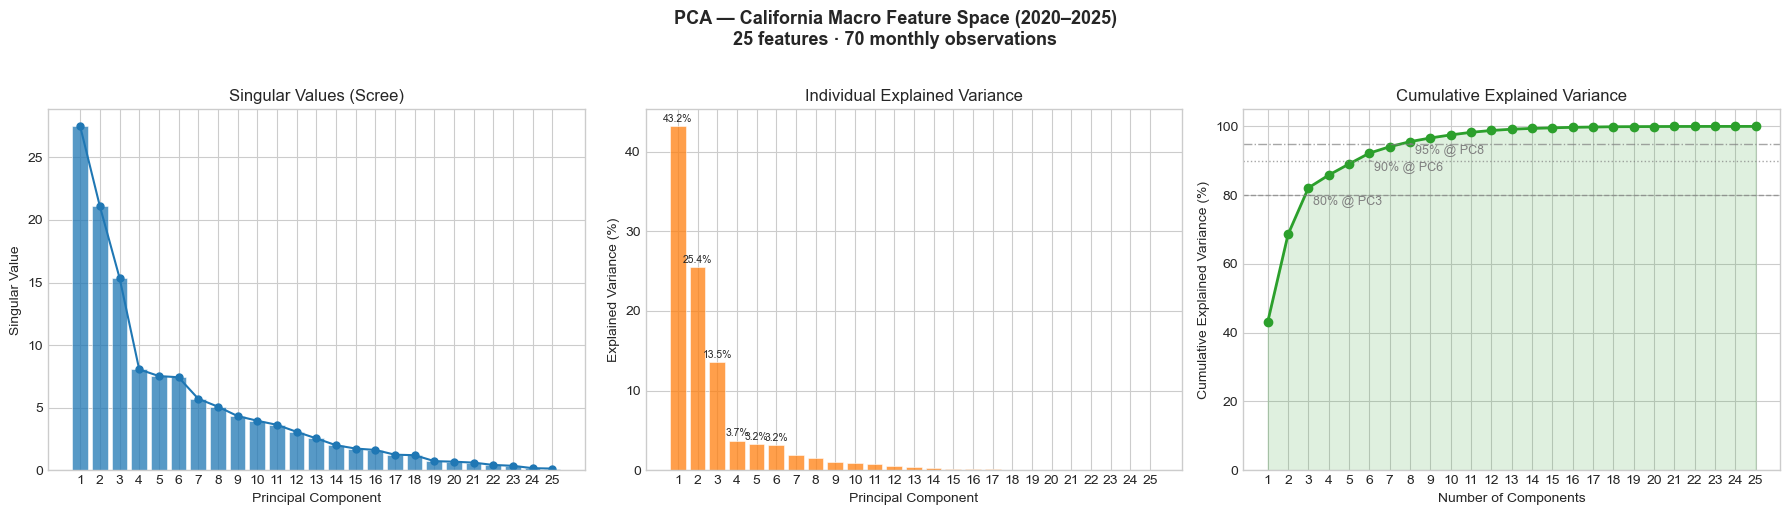

Saved → /Users/youtao/code/claude_code/lock_in/data/pca_scree.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    "PCA — California Macro Feature Space (2020–2025)\n"
    f"{df_clean.shape[1]} features · {df_clean.shape[0]} monthly observations",
    fontsize=13, fontweight="bold", y=1.02,
)

colors = plt.cm.tab10.colors
pc_idx = np.arange(1, n_pc + 1)

# ── Left: raw singular values ─────────────────────────────────────────────────
ax = axes[0]
ax.bar(pc_idx, svs, color=colors[0], alpha=0.75, edgecolor="white", linewidth=0.5)
ax.plot(pc_idx, svs, "o-", color=colors[0], markersize=5, lw=1.5)
ax.set_xlabel("Principal Component")
ax.set_ylabel("Singular Value")
ax.set_title("Singular Values (Scree)")
ax.set_xticks(pc_idx)

# ── Middle: individual explained variance bars ────────────────────────────────
ax = axes[1]
bars = ax.bar(pc_idx, evr * 100, color=colors[1], alpha=0.75, edgecolor="white",
              linewidth=0.5, label="Individual")
ax.set_xlabel("Principal Component")
ax.set_ylabel("Explained Variance (%)")
ax.set_title("Individual Explained Variance")
ax.set_xticks(pc_idx)
for bar, val in zip(bars, evr * 100):
    if val > 3:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                f"{val:.1f}%", ha="center", va="bottom", fontsize=7.5)

# ── Right: cumulative explained variance ──────────────────────────────────────
ax = axes[2]
ax.plot(pc_idx, cumvar * 100, "o-", color=colors[2], markersize=6, lw=2)
ax.fill_between(pc_idx, cumvar * 100, alpha=0.15, color=colors[2])
for thresh, ls in [(0.80, "--"), (0.90, ":"), (0.95, "-.")]:
    n_needed = int(np.argmax(cumvar >= thresh) + 1)
    ax.axhline(thresh * 100, ls=ls, color="grey", lw=1, alpha=0.7)
    ax.annotate(
        f"{int(thresh*100)}% @ PC{n_needed}",
        xy=(n_needed, thresh * 100),
        xytext=(n_needed + 0.25, thresh * 100 - 3),
        fontsize=9, color="grey",
        arrowprops=dict(arrowstyle="-", color="grey", lw=0.8),
    )
ax.set_xlabel("Number of Components")
ax.set_ylabel("Cumulative Explained Variance (%)")
ax.set_title("Cumulative Explained Variance")
ax.set_xticks(pc_idx)
ax.set_ylim(0, 105)

plt.tight_layout()
out_path = os.path.join(DATA_DIR, "pca_scree.png")
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {out_path}")


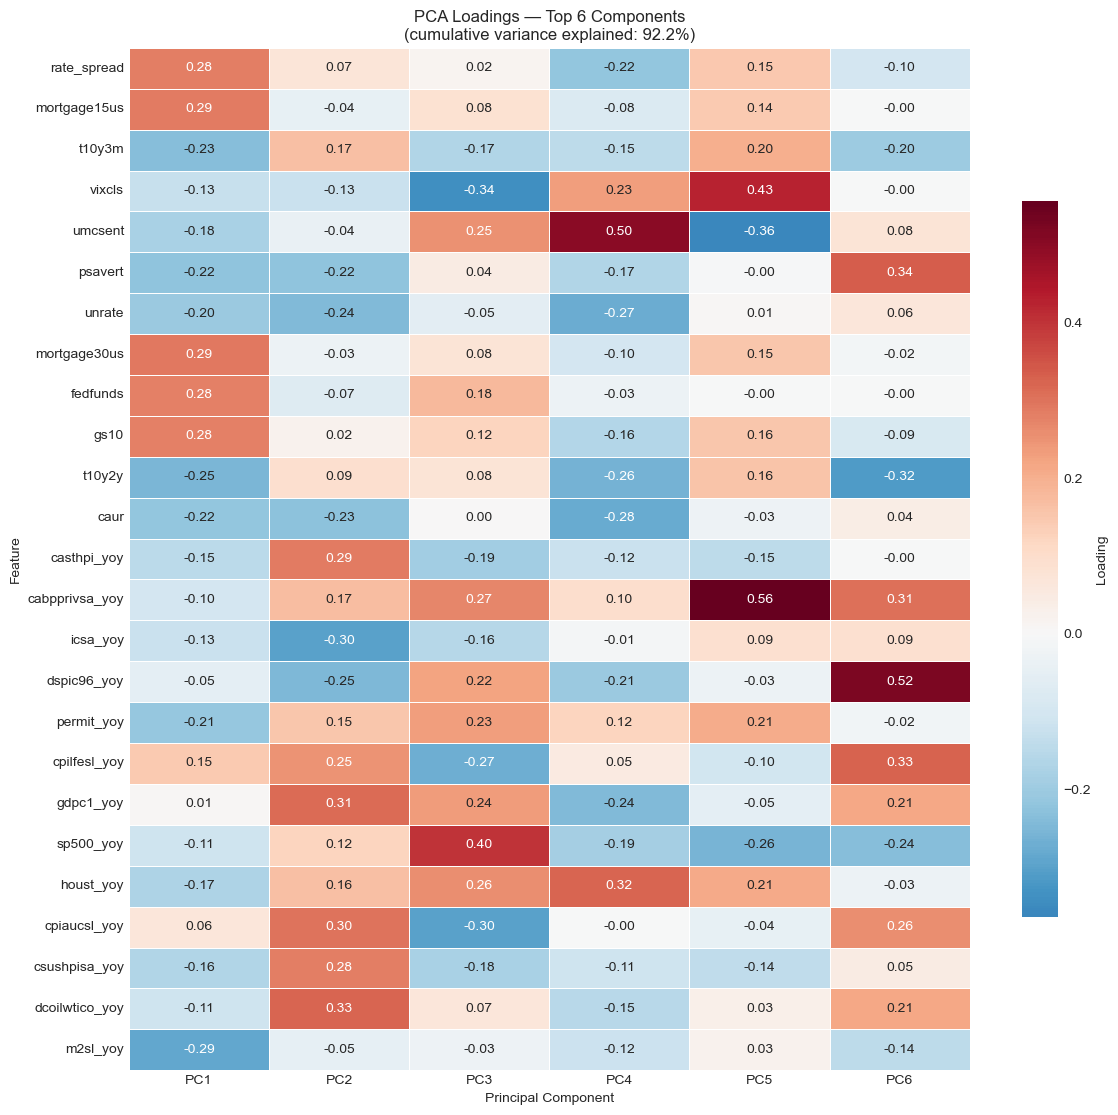

Saved → /Users/youtao/code/claude_code/lock_in/data/pca_loadings.png


In [9]:
# Show which original features load most heavily on the top PCs
n_show = min(6, n_pc)
loadings = pd.DataFrame(
    pca.components_[:n_show].T,
    index=df_clean.columns,
    columns=[f"PC{i}" for i in range(1, n_show + 1)],
)

fig, ax = plt.subplots(figsize=(min(12, n_show * 2), max(8, len(df_clean.columns) * 0.45)))
sns.heatmap(
    loadings, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
    linewidths=0.4, linecolor="white",
    cbar_kws={"label": "Loading", "shrink": 0.7},
    ax=ax,
)
ax.set_title(
    f"PCA Loadings — Top {n_show} Components\n"
    f"(cumulative variance explained: {cumvar[n_show-1]:.1%})",
    fontsize=12,
)
ax.set_xlabel("Principal Component")
ax.set_ylabel("Feature")
plt.tight_layout()
out_path2 = os.path.join(DATA_DIR, "pca_loadings.png")
plt.savefig(out_path2, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {out_path2}")


In [ ]:
if target_aligned is not None and target_aligned.notna().any():
    X_pca = pca.transform(X_scaled)
    pc_df  = pd.DataFrame(
        X_pca, index=df_clean.index,
        columns=[f"PC{i}" for i in range(1, n_pc + 1)],
    )
    corr = pc_df.corrwith(target_aligned).rename("r_with_target")

    print("Pearson r between each PC and CA new listing YoY % change:")
    print(f"{'PC':<5}  {'r':>8}  {'|r|':>6}  {'Expl.Var%':>10}")
    print("─" * 38)
    for i, (pc, r) in enumerate(corr.items(), 1):
        print(f"{pc:<5}  {r:>8.4f}  {abs(r):>6.4f}  {evr[i-1]*100:>9.2f}%")
else:
    print("Target not available — skipping PC correlation analysis.")


Pearson r between each PC and CA new listing YoY % change:
PC            r     |r|   Expl.Var%
──────────────────────────────────────
PC1     -0.2906  0.2906      43.16%
PC2      0.2384  0.2384      25.45%
PC3      0.5960  0.5960      13.53%
PC4     -0.0601  0.0601       3.71%
PC5      0.1380  0.1380       3.23%
PC6     -0.4217  0.4217       3.15%
PC7      0.1444  0.1444       1.86%
PC8      0.0424  0.0424       1.47%
PC9     -0.0852  0.0852       1.07%
PC10     0.0275  0.0275       0.89%
PC11     0.2730  0.2730       0.75%
PC12    -0.0129  0.0129       0.54%
PC13     0.1754  0.1754       0.37%
PC14     0.0603  0.0603       0.23%
PC15    -0.0925  0.0925       0.17%
PC16     0.0192  0.0192       0.15%
PC17    -0.0977  0.0977       0.09%
PC18    -0.1439  0.1439       0.08%
PC19    -0.0971  0.0971       0.03%
PC20     0.0508  0.0508       0.03%
PC21    -0.0620  0.0620       0.02%
PC22     0.0270  0.0270       0.01%
PC23     0.0876  0.0876       0.01%
PC24    -0.0947  0.0947       0.00%
PC

## 4. Time Series Model: Target on PC1 (Dominant Eigenvector)

Use SARIMAX (ARIMA with exogenous regressors + seasonality) to model CA new listing YoY % change as a function of PC1, while capturing autoregressive structure and monthly seasonality.

In [50]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

if target_aligned is not None and target_aligned.notna().any():
    # Get PC1 scores (dominant eigenvector projection)
    X_pca = pca.transform(X_scaled)
    pc1 = X_pca[:, 4]  # first principal component (dominant eigenvector)

    # Align and drop rows with missing target
    valid = target_aligned.notna()
    y = target_aligned.loc[valid]
    exog = pd.DataFrame({"PC1": pc1[valid.values]}, index=y.index)

    # SARIMAX: ARIMA(1,0,1) + seasonal(1,0,1,12), exogenous PC1
    # Simpler order for robustness with ~70 monthly obs
    model = SARIMAX(
        y, exog=exog,
        order=(1, 0, 1),
        seasonal_order=(1, 0, 1, 12),
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    fit = model.fit(disp=False)

    print(fit.summary())
    print()
    # Pseudo-R²: 1 - (SS_res / SS_tot) from fitted values
    y_hat = fit.fittedvalues
    ss_res = ((y - y_hat) ** 2).sum()
    ss_tot = ((y - y.mean()) ** 2).sum()
    pseudo_r2 = 1 - (ss_res / ss_tot)
    print(f"→ Pseudo-R² (fit vs. mean): {pseudo_r2:.2%}")
else:
    print("Target not available or has missing values — cannot run model.")

                                     SARIMAX Results                                      
Dep. Variable:                  ca_newlisting_yoy   No. Observations:                   70
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 12)   Log Likelihood                -202.061
Date:                            Wed, 04 Mar 2026   AIC                            416.123
Time:                                    18:50:46   BIC                            428.275
Sample:                                01-01-2020   HQIC                           420.834
                                     - 10-01-2025                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
PC1            2.7762      2.081      1.334      0.182      -1.302       6.855
ar.L1          0.9213      0.092   

In [42]:
np.shape(X_pca)

(70, 25)

In [43]:
import statsmodels.api as sm
for i, pc in enumerate(np.transpose(X_pca)):
    if target_aligned is not None and target_aligned.notna().any():
        # Get PC1 scores (dominant eigenvector projection)
        X_pca = pca.transform(X_scaled)

        # Align and drop rows with missing target
        valid = target_aligned.notna()
        y = target_aligned.loc[valid].values
        X = sm.add_constant(pc[valid.values])

        model = sm.OLS(y, X).fit()
        print("pc", i, model.rsquared)

pc 0 0.08445510728595562
pc 1 0.05685235574508607
pc 2 0.3552290099625125
pc 3 0.0036116222284736654
pc 4 0.01903923995582979
pc 5 0.17784288375333557
pc 6 0.020840856290117005
pc 7 0.0017964427197428856
pc 8 0.007253369768778661
pc 9 0.0007559639686915975
pc 10 0.07453667908822104
pc 11 0.00016707320346143195
pc 12 0.030749398071458822
pc 13 0.0036383536081604495
pc 14 0.008558680900539795
pc 15 0.00036701165132568825
pc 16 0.009535732356669047
pc 17 0.02070093904097392
pc 18 0.009425861729972729
pc 19 0.0025800734394018088
pc 20 0.0038465074596872872
pc 21 0.0007285688051227313
pc 22 0.007672213896588231
pc 23 0.008971835774721049
pc 24 0.004886040691671201
